# Eksperyment 6: Wpływ rozdzielczości obrazu na jakość opisu

**Przedmiot:** ADOM  
**Metoda:** Show and Tell - automatyczne opisywanie obrazów  
**Data realizacji:** Maj 2026

---

## Cel eksperymentu

Zbadanie jak degradacja rozdzielczości obrazu wejściowego wpływa na jakość
generowanych opisów.

**Hipoteza:** Przy skrajnie niskich rozdzielczościach opisy staną się generyczne
lub błędne, a krzywa BLEU-4 będzie opadać wraz ze spadkiem rozdzielczości.

---

## Metodologia

Model zawsze otrzymuje obraz 256×256 - taki jest rozmiar wejściowy enkodera.
Degradację symulujemy przez dwukrotny resize:
1. Obraz → docelowa rozdzielczość (np. 32×32) algorytmem NEAREST
2. Wynik → z powrotem do 256×256 algorytmem NEAREST

Użycie NEAREST (kopiowanie najbliższego piksela) gwarantuje prawdziwy efekt
pikselizacji - bloki kwadratowe bez rozmycia krawędzi.

**Metryka:** BLEU-4 obliczane dla każdego poziomu rozdzielczości.

| Rozdzielczość | Opis |
|---------------|------|
| 256×256 | natywna - baseline |
| 224×224 | minimalna degradacja |
| 128×128 | umiarkowana degradacja |
| 96×96 | wyraźna degradacja |
| 64×64 | silna degradacja |
| 48×48 | bardzo silna degradacja |
| 32×32 | skrajna degradacja |

In [2]:
import sys, os, json, torch, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Seeding for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORD_MAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
VAL_IMAGES_DIR = '../dataset/val2014'
DATASET_JSON = '../dataset/caption_datasets/dataset_coco.json'

SAMPLE_SIZE = 1000
BEAM_SIZE = 3

# Load Metadata
with open(WORD_MAP_PATH, 'r') as j: word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(MODEL_PATH, map_location=str(DEVICE), weights_only=False)
decoder, encoder = checkpoint['decoder'].to(DEVICE).eval(), checkpoint['encoder'].to(DEVICE).eval()

# Rigorous Sampling: Verify file existence BEFORE sampling to prevent sample shrinkage
with open(DATASET_JSON, 'r') as j:
    all_test_images = [img for img in json.load(j)['images'] if img['split'] == 'test']

valid_images = []
for img in all_test_images:
    if os.path.exists(os.path.join(VAL_IMAGES_DIR, img['filename'])):
        valid_images.append(img)

sampled_images = random.sample(valid_images, min(SAMPLE_SIZE, len(valid_images)))
references_dict = {img['filename']: [c['tokens'] for c in img['sentences']] for img in sampled_images}

print(f"Sampling complete: {len(references_dict)} images ready.")

Sampling complete: 1000 images ready.


## Funkcja degradacji rozdzielczości

Symulacja pikselizacji przez downscale → upscale z algorytmem NEAREST.

In [3]:
def get_degraded_image(image_path, target_res):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((256, 256), Image.LANCZOS)
    
    if target_res != 256:
        img = img.resize((target_res, target_res), Image.NEAREST)
        img = img.resize((256, 256), Image.NEAREST)
        
    return img

## Ewaluacja

Dla każdej z 7 rozdzielczości generujemy opisy dla N=1000 obrazów
i obliczamy BLEU-4.

In [4]:
resolutions = [256, 224, 128, 96, 64, 48, 32]
resolution_results = {}

for res in resolutions:
    label = f"{res}x{res}" if res != 256 else "256x256 (Native)"
    actual_refs, actual_hyps = [], []

    for filename, refs in tqdm(references_dict.items(), desc=f"Eval {label}"):
        img = get_degraded_image(os.path.join(VAL_IMAGES_DIR, filename), res)
        seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
        hypothesis = [rev_word_map[w] for w in seq
                      if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        actual_refs.append(refs)
        actual_hyps.append(hypothesis)

    resolution_results[res] = {
    'Label': label,
    'BLEU4': corpus_bleu(actual_refs, actual_hyps, weights=(0.25, 0.25, 0.25, 0.25)),
}

Eval 32x32: 100%|██████████| 1000/1000 [01:01<00:00, 16.13it/s]


## Wyniki

Krzywa degradacji BLEU-4 w funkcji rozdzielczości wejściowej.

,Label,BLEU4,Drop_vs_Baseline
256,256x256 (Native),0.3363,0.0%
224,224x224,0.3291,-2.1%
128,128x128,0.2544,-24.4%
96,96x96,0.1394,-58.5%
64,64x64,0.0807,-76.0%
48,48x48,0.0504,-85.0%
32,32x32,0.0453,-86.5%


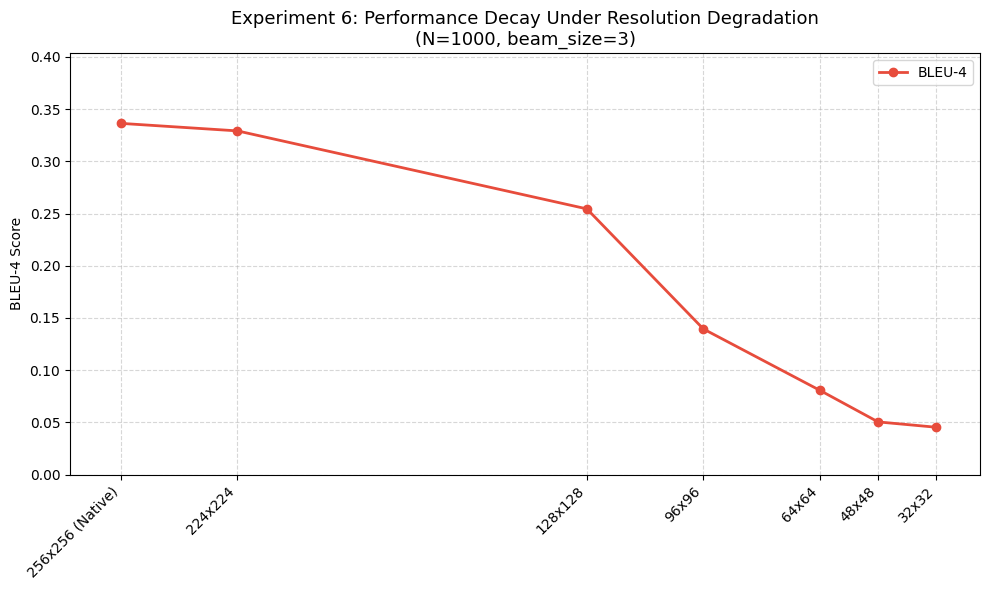

In [5]:
df_res = pd.DataFrame.from_dict(resolution_results, orient='index').sort_index(ascending=False)

baseline = df_res['BLEU4'].iloc[0]
df_res['Drop_vs_Baseline'] = ((df_res['BLEU4'] - baseline) / baseline * 100).round(1).astype(str) + '%'

display(df_res[['Label', 'BLEU4', 'Drop_vs_Baseline']].round(4))

fig, ax = plt.subplots(figsize=(10, 6))

x_vals = df_res.index.astype(int)
ax.plot(x_vals, df_res['BLEU4'], marker='o', linewidth=2, color='#e74c3c', label='BLEU-4')

ax.set_xticks(x_vals)
ax.set_xticklabels(df_res['Label'], rotation=45, ha='right')
ax.set_title('Experiment 6: Performance Decay Under Resolution Degradation\n(N=1000, beam_size=3)', fontsize=13)
ax.set_ylabel('BLEU-4 Score')
ax.set_xlim(270, 20)
ax.set_ylim(0, df_res['BLEU4'].max() * 1.2)
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

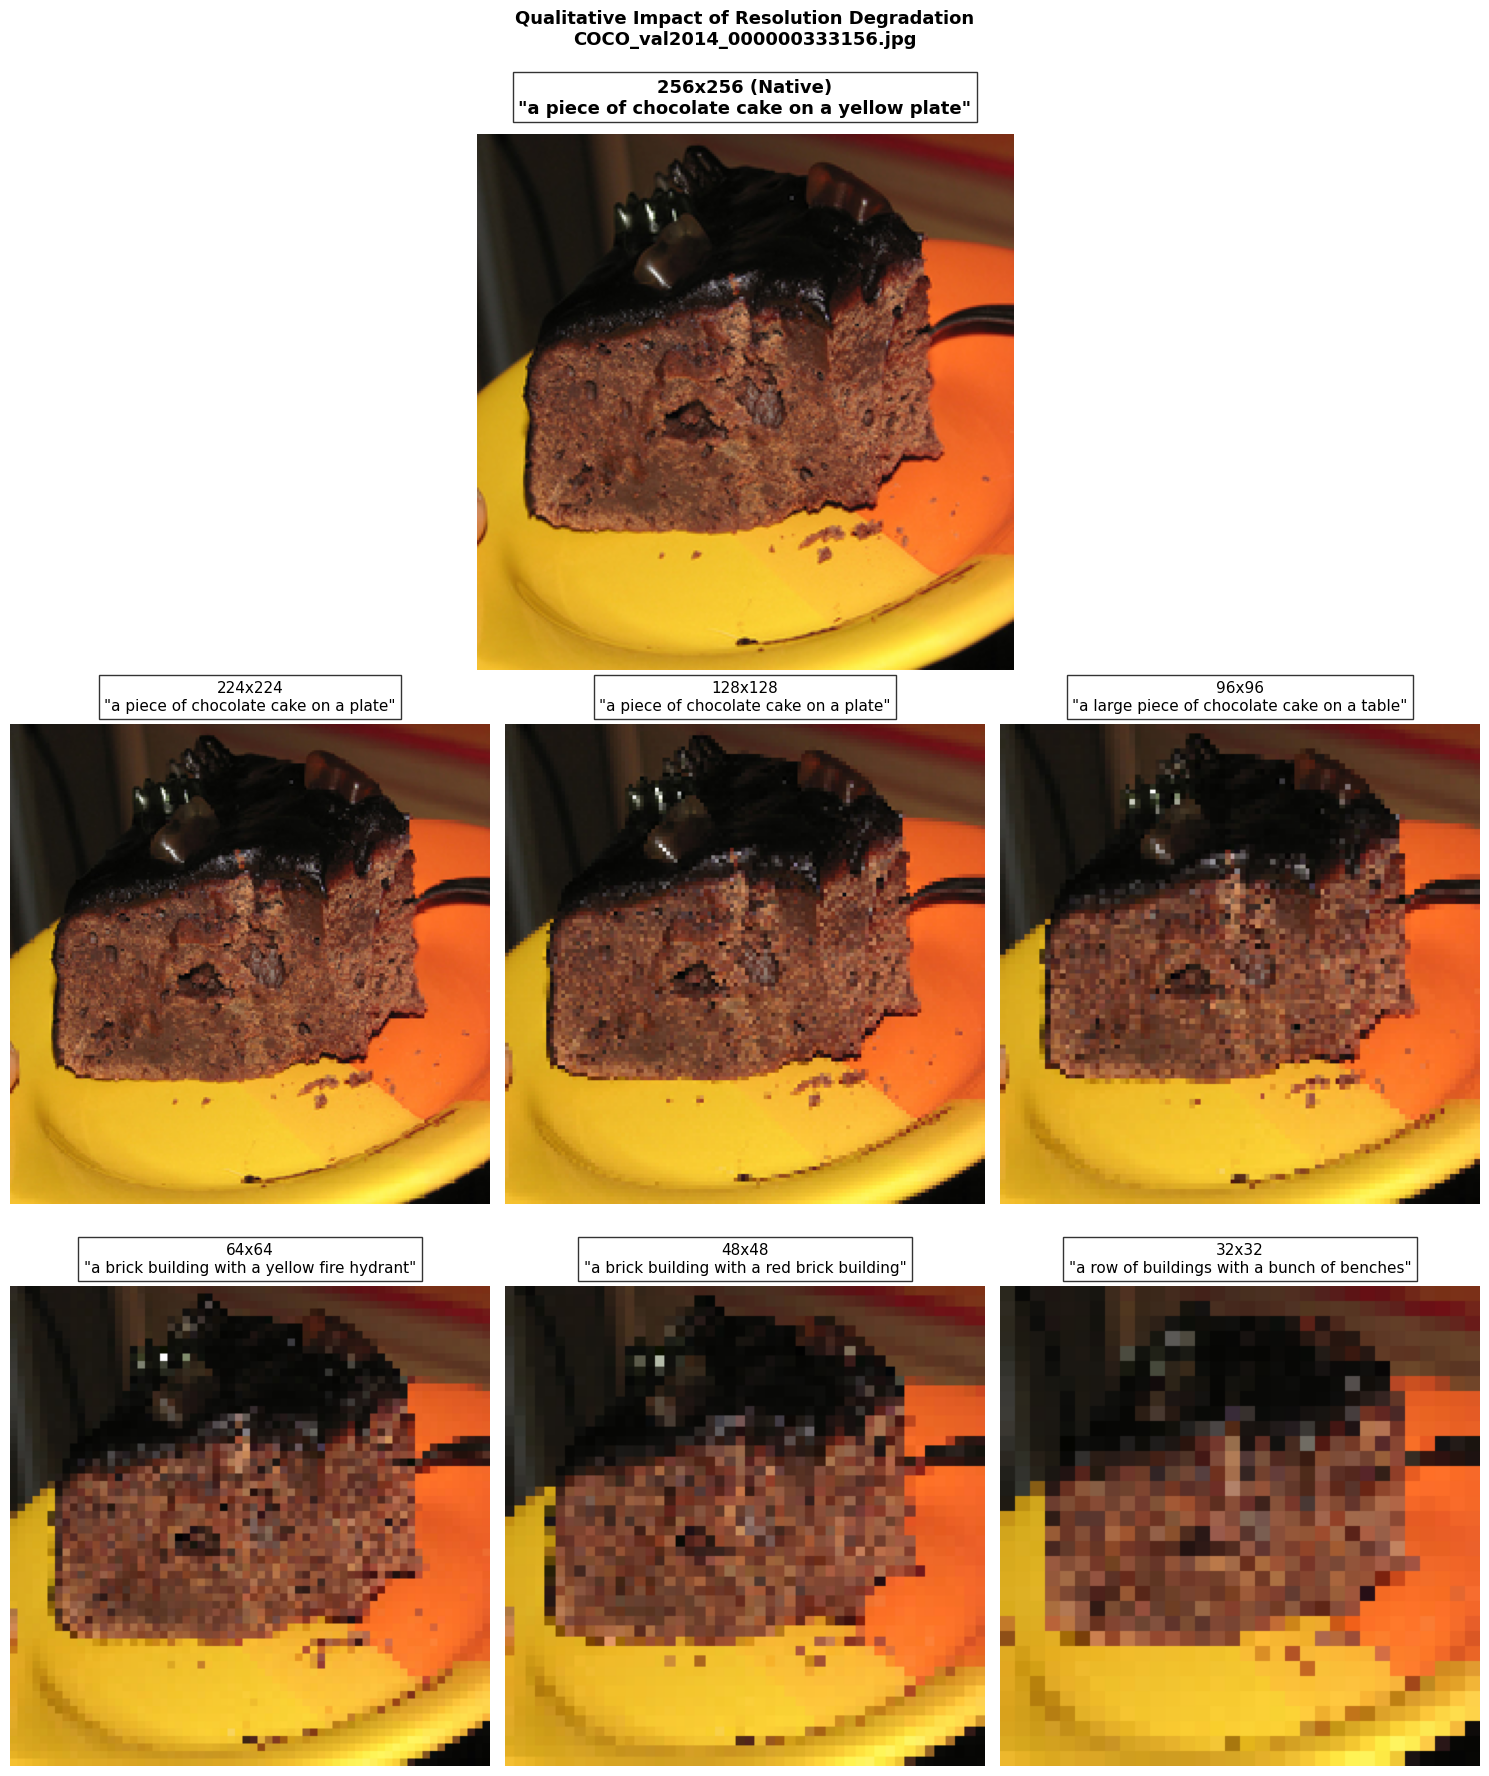

In [6]:
sample_filename = random.choice(list(references_dict.keys()))
sample_path = os.path.join(VAL_IMAGES_DIR, sample_filename)

vis_resolutions = [256, 224, 128, 96, 64, 48, 32]

fig = plt.figure(figsize=(15, 18))
fig.suptitle(f'Qualitative Impact of Resolution Degradation\n{sample_filename}',
             fontsize=13, fontweight='bold', y=1.0)

# --- Top: large native image ---
ax_native = fig.add_subplot(3, 1, 1)
img = get_degraded_image(sample_path, 256)
seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
hyp = " ".join([rev_word_map[w] for w in seq
                if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])
ax_native.imshow(img)
ax_native.axis('off')
ax_native.set_title(f'256x256 (Native)\n"{hyp}"', fontsize=13, fontweight='bold',
                    pad=15, bbox=dict(facecolor='white', alpha=0.8))

# --- Bottom: 2x3 grid of degraded images ---
for i, res in enumerate(vis_resolutions[1:]):
    ax = fig.add_subplot(3, 3, i + 4)
    img = get_degraded_image(sample_path, res)
    seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
    hyp = " ".join([rev_word_map[w] for w in seq
                    if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{res}x{res}\n"{hyp}"', fontsize=11, pad=10,
                 bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Wnioski

**Wyniki (N=1000, beam_size=3):**

| Rozdzielczość | BLEU-4 | Spadek vs baseline |
|---------------|--------|--------------------|
| 256×256 (Native) | 0.336 | - |
| 224×224 | 0.329 | -2% |
| 128×128 | 0.254 | -24% |
| 96×96 | 0.139 | -59% |
| 64×64 | 0.081 | -76% |
| 48×48 | 0.050 | -85% |
| 32×32 | 0.045 | -87% |

**Obserwacje:**
- Do rozdzielczości 224×224 model praktycznie nie traci jakości (-2%) -
  enkoder ResNet jest odporny na minimalną degradację.
- Wyraźny punkt przełomowy następuje między 128×128 a 96×96 - BLEU-4
  spada z 0.254 do 0.139 (prawie o połowę). Poniżej 96×96 obiekty
  przestają być rozpoznawalne.
- Między 48×48 a 32×32 krzywa wypłaszcza się - model osiąga "dno"
  i generuje równie złe opisy niezależnie od dalszej degradacji.
- Przy 32×32 model generuje skrajnie generyczne opisy niezależne
  od rzeczywistej treści obrazu.